# Bike Sharing Demand Analysis

## Project Objective

This project analyzes bike rental demand using the Bike Sharing dataset.

The goal is to understand how factors such as time, weather, season, temperature, and working days affect the number of bike rentals.

### Key Areas of Analysis
- Rental demand over time
- Rental demand by hour
- Weather conditions
- Seasonal patterns
- Temperature and rental demand
- Working days vs. non-working days

**Tools:** Python, Pandas, Matplotlib, Google Colab



In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# Dataset overview
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Shape: (10886, 12)

Columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

Missing values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Basic statistics:


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


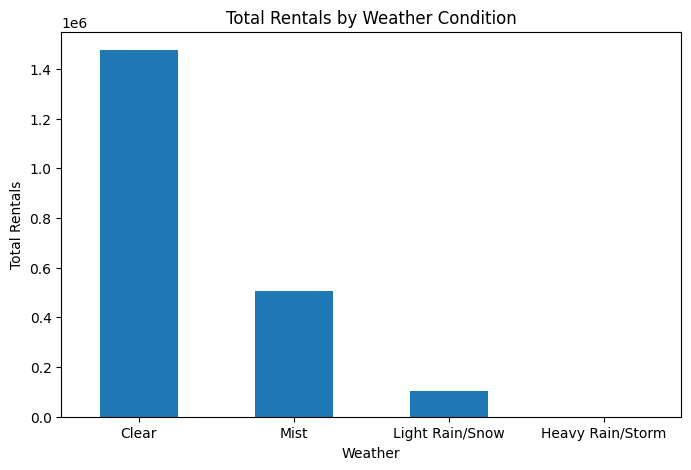

In [8]:
# Total bike rentals by weather condition
weather_demand = df.groupby('weather')['count'].sum()

weather_labels = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Storm'
}

weather_demand.index = weather_demand.index.map(weather_labels)

plt.figure(figsize=(8, 5))
weather_demand.plot(kind='bar')

plt.title('Total Rentals by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Total Rentals')
plt.xticks(rotation=0)
plt.show()

Rental demand is highest under favorable weather conditions and decreases as weather conditions become worse.

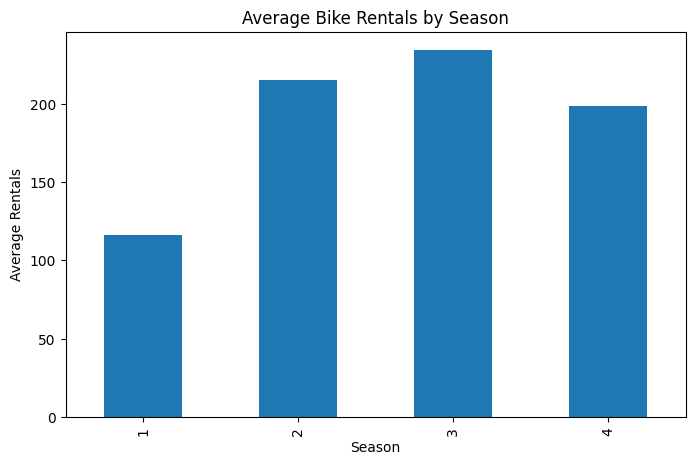

In [6]:
season_avg = df.groupby("season")["count"].mean()

season_avg.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Bike Rentals by Season"
)

plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()

Rental demand is highest in Season 3, followed by Season 2 and Season 4. Season 1 has the lowest average demand.

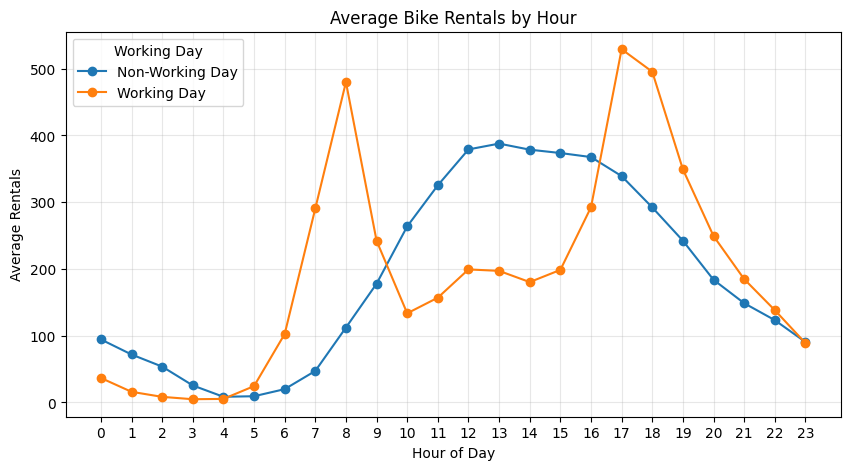

In [10]:
# Average bike rentals by hour and working day
df['hour'] = pd.to_datetime(df['datetime']).dt.hour

hourly_working = df.groupby(['hour', 'workingday'])['count'].mean().unstack()

plt.figure(figsize=(10, 5))

plt.plot(hourly_working.index, hourly_working[0], marker='o', label='Non-Working Day')
plt.plot(hourly_working.index, hourly_working[1], marker='o', label='Working Day')

plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.xticks(range(24))
plt.legend(title='Working Day')
plt.grid(True, alpha=0.3)

plt.show()

Key Observation: Bike rental demand varies significantly by hour. On working days, demand peaks around 8 AM and 5–6 PM, reflecting commuting patterns. On non-working days, demand is more spread throughout the day, with higher activity around the afternoon. Demand is generally low during the early morning and late-night hours.

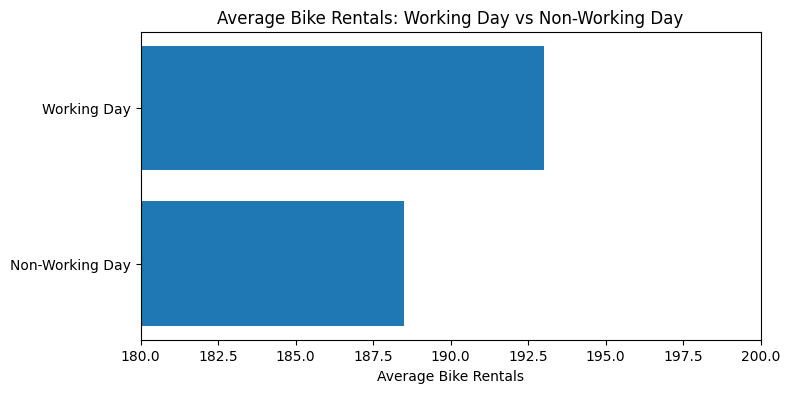

In [7]:
# Average rentals: Working Day vs Non-Working Day

working_day_demand = df.groupby('workingday')['count'].mean()

plt.figure(figsize=(8, 4))

plt.barh(
    ['Non-Working Day', 'Working Day'],
    working_day_demand.values
)

plt.xlabel('Average Bike Rentals')
plt.title('Average Bike Rentals: Working Day vs Non-Working Day')

# Zoom in to make the difference easier to see
plt.xlim(180, 200)

plt.show()

# Conclusion

The analysis shows that bike rental demand is influenced by several factors.

Demand varies significantly throughout the day, with the highest rental activity occurring during peak hours. Weather and season also affect rental demand, while temperature shows a generally positive relationship with rentals.

Overall, the analysis provides useful insights into the patterns and factors that influence bike-sharing demand.